Listes des Tickers (Sympboles boursiers) du projet divisés en 4 groupes puis réunies

In [2]:
commodities_and_macro = ['USO', 'CGW', 'PICK', '^VIX', '^TNX']  # 'USO' (Pétrole), 'CGW' (Eau), 'PICK' (Métaux/Silicium), '^VIX' (Peur), '^TNX' (Taux d'intérêt)
foundries_and_equipment = ['ASML', 'TSM', '0981.HK'] # 'TSM' (TSMC), '0981.HK' (SMIC / Proxy Huawei Chine)
fabless_designers = ['NVDA', 'AMD', 'INTC', 'AVGO'] # 'AVGO' (Broadcom)
integrators_and_ai = ['AAPL', 'MSFT', 'GOOGL', 'TSLA'] # 'MSFT' (Proxy OpenAI), 'GOOGL' (Proxy Anthropic)

all_tickers = commodities_and_macro + foundries_and_equipment + fabless_designers + integrators_and_ai

print("Nombres total de tickers : ", len(all_tickers))
print ("Tickers : ", all_tickers)

Nombres total de tickers :  16
Tickers :  ['USO', 'CGW', 'PICK', '^VIX', '^TNX', 'ASML', 'TSM', '0981.HK', 'NVDA', 'AMD', 'INTC', 'AVGO', 'AAPL', 'MSFT', 'GOOGL', 'TSLA']


Imports

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [8]:
data = yf.download(all_tickers, start="2010-01-01", end="2025-12-31")['Close']

os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

data.to_csv('../data/raw/chip_chain_raw.csv')

[*********************100%***********************]  16 of 16 completed


Problème car certaines valeur vide :
- Certains n'étaient toujours pas en bourse en 2010
- Huawei représenter par 0981.HK est en bourse asiatique mais les bourses américaines n'ont pas les mêmes jours fériés

In [ ]:
# Si la donnée est vide car bourse américaine férmée ou asiatique, on peut la remplir avec la dernière valeur connue
data_filled = data.ffill()

# Puisque certaines entreprises ont été introduites en bourse plus récemment, ainsi on supprime les lignes d'avant pour tous les tickers
data_filled = data_filled.dropna()

data_filled.to_csv('../data/processed/chip_chain_processed.csv')

In [13]:
print("Nombre de NaN dans data_filled : ", data_filled.isna().sum().sum()) 

Nombre de NaN dans data_filled :  0


Après d'avoir préparer la donnée, on calcul les ratios des prix

In [14]:
# Calculer les rendements quotidiens
daily_returns = data_filled.pct_change().dropna()

On a calculé le rendement R = (Prix(t) / Prix(t-1)) - 1

### Le problème du rendement simple est que l'on a pas de symétrie ni une addition clair :
- Une action de 100€ perd 50%, alors elle passe à 50€ mais pour revenir à 100€ il ne faut pas faire +50% mais +100%
- Une action passe le jour 1 de 100 à 110, puis jour 2 de 110 à 121, chaque jour elle fait +10% mais en tout elle fait +21%
#### Ainsi on passe en logarithme pour que cela fonctionne

In [15]:
# Passer à des rendemments logarithmiques
log_returns = np.log(1 + daily_returns)

On retrouve bien ln(Prix(t) / Prix(t-1))

On sauvegarde les deux données créées

In [16]:
# Sauvegarde des rendements simples et logarithmiques
daily_returns.to_csv('../data/processed/chip_chain_daily_returns.csv')
log_returns.to_csv('../data/processed/chip_chain_log_returns.csv')

On affiche les résultats pour log

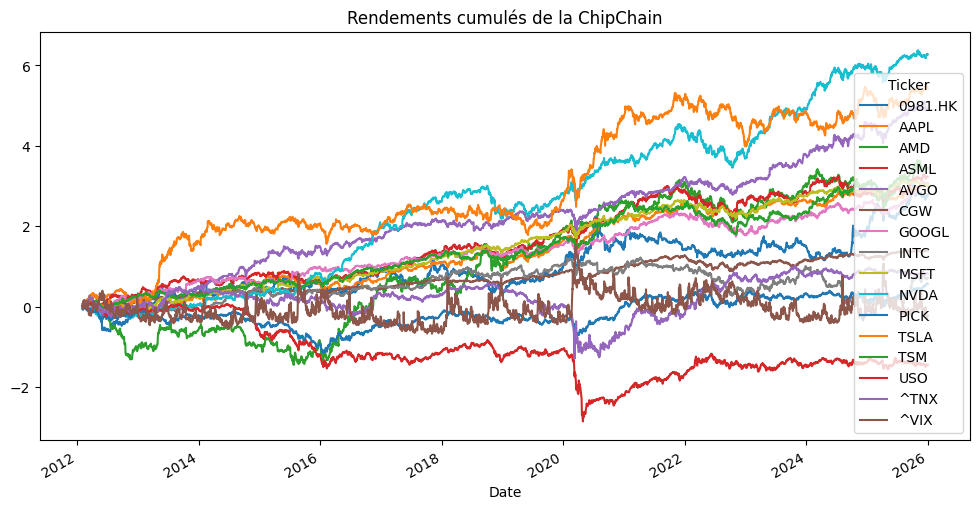

In [18]:
log_returns.cumsum().plot(figsize=(12, 6), title="Rendements cumulés de la ChipChain")
plt.show()